# Phase 1 — Data Exploration

Multimodal CVD (stroke) risk project — EDA on the patient cohort built from the Coherent dataset's FHIR bundles.

Cohort construction lives in `src/data/parse_fhir.py`; this notebook loads the resulting `data/processed/patient_cohort.csv` and explores it: class balance, MRI availability, feature correlations, and a sample MRI slice.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("..") / "data"
cohort = pd.read_csv(DATA_DIR / "processed" / "patient_cohort.csv")
cohort.shape

(1278, 12)

## Cohort overview

In [2]:
cohort.info()

<class 'pandas.DataFrame'>
RangeIndex: 1278 entries, 0 to 1277
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         1278 non-null   str    
 1   sex                1278 non-null   str    
 2   age                1278 non-null   int64  
 3   glucose            956 non-null    float64
 4   total_cholesterol  1165 non-null   float64
 5   hdl_cholesterol    1165 non-null   float64
 6   bmi                1175 non-null   float64
 7   diastolic_bp       1175 non-null   float64
 8   systolic_bp        1175 non-null   float64
 9   smoking_status     1175 non-null   str    
 10  label              1278 non-null   int64  
 11  mri_file_path      298 non-null    str    
dtypes: float64(6), int64(2), str(4)
memory usage: 245.3 KB


In [3]:
missing_pct = (cohort.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_pct

mri_file_path        76.7
glucose              25.2
total_cholesterol     8.8
hdl_cholesterol       8.8
diastolic_bp          8.1
systolic_bp           8.1
smoking_status        8.1
bmi                   8.1
age                   0.0
sex                   0.0
patient_id            0.0
label                 0.0
dtype: float64

## Label balance

The label marks whether a patient has a stroke/cerebrovascular disease diagnosis in their FHIR record (see `parse_fhir.py`'s `CVD_KEYWORDS`). It's scoped to stroke specifically rather than the broader CVD basket (AFib, coronary heart disease, heart failure, etc.) — the only imaging modality available is brain MRI, which has real signal for stroke but essentially none for cardiac-only conditions. A broader label was tried first and came out 93% positive / 7% negative, driven mostly by cardiac diagnoses a brain scan has no evidence for; narrowing to stroke brings it to a workable, more meaningful split.

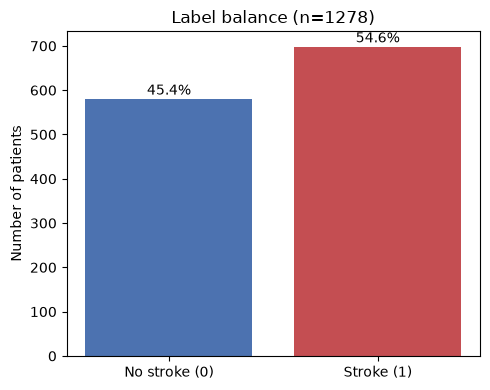

(label
 0    580
 1    698
 Name: count, dtype: int64,
 label
 0    45.4
 1    54.6
 Name: proportion, dtype: float64)

In [4]:
label_counts = cohort["label"].value_counts().sort_index()
label_pct = cohort["label"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["No stroke (0)", "Stroke (1)"], label_counts.values, color=["#4C72B0", "#C44E52"])
for bar, pct in zip(bars, label_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10, f"{pct:.1f}%", ha="center")
ax.set_ylabel("Number of patients")
ax.set_title(f"Label balance (n={len(cohort)})")
plt.tight_layout()
plt.show()

label_counts, label_pct.round(1)

## MRI availability

Only 298 of 1278 patients have a linked brain MRI scan — the rest never had one ordered in their synthetic record. Since Phases 4–6 need imaging, that 298-patient subset becomes the effective cohort for imaging-only, EHR-only, and fused models alike (see "Decisions carried into Phases 4–6" below).

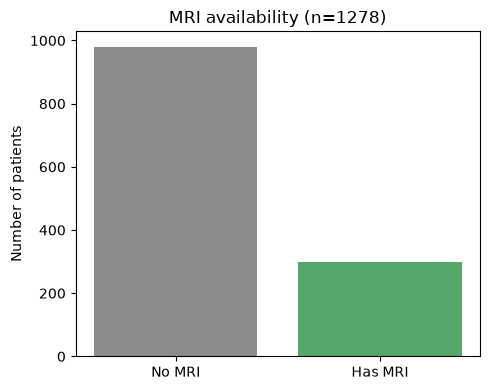

,No MRI (%),Has MRI (%)
No stroke (0),77.6,22.4
Stroke (1),75.9,24.1


In [5]:
cohort["has_mri"] = cohort["mri_file_path"].notna()

availability_counts = cohort["has_mri"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["No MRI", "Has MRI"], availability_counts.values, color=["#8C8C8C", "#55A868"])
ax.set_ylabel("Number of patients")
ax.set_title(f"MRI availability (n={len(cohort)})")
plt.tight_layout()
plt.show()

# does MRI availability skew by label? (it shouldn't, and doesn't)
crosstab = pd.crosstab(cohort["label"], cohort["has_mri"], normalize="index").round(3) * 100
crosstab.columns = ["No MRI (%)", "Has MRI (%)"]
crosstab.index = ["No stroke (0)", "Stroke (1)"]
crosstab

## Decisions carried into Phases 4–6

- **Cohort scope:** all three models in the Phase 4–6 comparison (imaging-only, EHR-only, and fused) train and evaluate on the same 298-patient MRI subset, not the full 1278-patient cohort. The EHR-only baseline could technically use more data, but doing so would make the three-way comparison table apples-to-oranges — the fused and imaging models are hard-capped at 298 patients since that's all the MRI data there is, so the EHR baseline needs to match to keep the comparison fair.
- **Small-N handling:** 298 patients is small for deep learning. Phases 4–6 use k-fold cross-validation instead of a single train/test split, and this gets documented as an explicit limitation in the final README (small sample, synthetic data, not clinically validated).

## Feature correlations

Correlation among the numeric EHR fields, and each field's correlation with the (stroke) label.

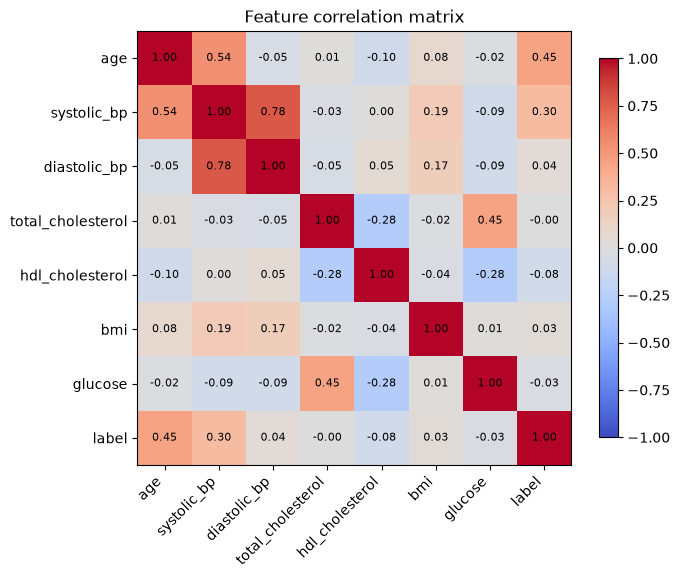

age                  0.450605
systolic_bp          0.297995
diastolic_bp         0.038895
bmi                  0.028613
total_cholesterol   -0.004242
glucose             -0.032705
hdl_cholesterol     -0.081430
Name: label, dtype: float64

In [6]:
numeric_cols = ["age", "systolic_bp", "diastolic_bp", "total_cholesterol", "hdl_cholesterol", "bmi", "glucose", "label"]
corr = cohort[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

corr["label"].drop("label").sort_values(ascending=False)

## Sample MRI slice

Each DICOM file is a full 3D brain volume (256×256×256 voxels, confirmed via `pydicom` — `NumberOfFrames=256`, `pixel_array.shape=(256, 256, 256)`). Slice indices roughly 0–49 and 205–255 are noise-only per the reference `mri` repo's README and get dropped in Phase 2 — shown below is one slice from that noisy range next to one from the clean middle range, for comparison.

volume shape: (256, 256, 256)


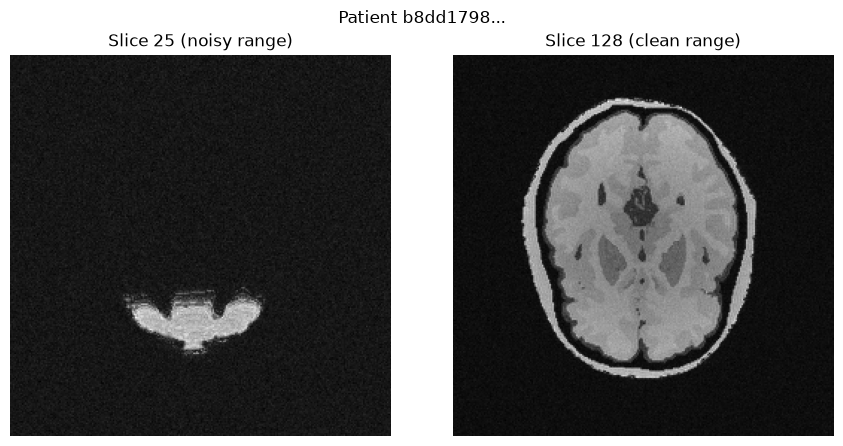

In [7]:
import pydicom

sample_row = cohort[cohort["has_mri"]].iloc[0]
ds = pydicom.dcmread(sample_row["mri_file_path"])
volume = ds.pixel_array
print("volume shape:", volume.shape)

noisy_idx = 25
clean_idx = volume.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(volume[noisy_idx], cmap="gray")
axes[0].set_title(f"Slice {noisy_idx} (noisy range)")
axes[0].axis("off")
axes[1].imshow(volume[clean_idx], cmap="gray")
axes[1].set_title(f"Slice {clean_idx} (clean range)")
axes[1].axis("off")
plt.suptitle(f"Patient {sample_row['patient_id'][:8]}...")
plt.tight_layout()
plt.show()

## Summary of key findings

- 1278 patients total; 298 (23%) have a linked brain MRI.
- Stroke-scoped label: 698 positive (54.6%) / 580 negative (45.4%) — a workable balance, reached only after narrowing from an initial 93%/7% broad-CVD definition that a brain-only imaging modality couldn't meaningfully inform.
- MRI availability is roughly independent of the label (~24% vs ~22%), so the 298-patient imaging subset isn't a biased sample of stroke status.
- Missingness in vitals/labs (BP, cholesterol, BMI, glucose) sits around 8–25% and will need handling in Phase 3's feature engineering.
- Phases 4–6 will use the 298-patient MRI subset as the common cohort for all three models (imaging-only, EHR-only, fused), evaluated with k-fold cross-validation given the small N — documented as a limitation in the final README.